# 🚗 Regional Vehicle Sales Analysis — India
### Data Analytics Course Project

---

## Project Overview

India is one of the world's largest automobile markets, selling over **22 million vehicles** every year across five segments and 28 states. But demand is far from uniform — a two-wheeler that dominates Uttar Pradesh barely registers in Goa. An EV booming in Karnataka has near-zero buyers in Bihar.

This project analyzes vehicle sales data across Indian states and regions from **FY2019 to FY2024** to surface patterns that matter for manufacturers, dealers, and policymakers.

---

## 8 Business Questions

### Category A — Regional Demand
- **BQ1:** Which states and regions lead in total vehicle sales volume, and how has that ranking shifted from FY2019 to FY2024?
- **BQ2:** Which states are growing fastest (by YoY % growth) and represent the highest-potential emerging markets?

### Category B — Segment & Mix
- **BQ3:** How does the segment mix (2W, 3W, PV, CV, EV) differ across regions, and which segment dominates each region?
- **BQ4:** Which vehicle segments are showing the strongest national growth trend, and which are declining?

### Category C — EV & Fuel Transition
- **BQ5:** How has EV adoption grown across states from FY2019 to FY2024, and which states are leading the transition?
- **BQ6:** How is the fuel-type mix (Petrol/Diesel/CNG/Electric) shifting over time?

### Category D — OEM & Market Structure
- **BQ7:** What is each major OEM's market share by segment, and which manufacturers dominate which regions?
- **BQ8:** What actionable recommendations can be made for OEMs, dealers, and policymakers?

---

### Segments Covered
| Segment | Sub-types |
|---|---|
| Two-Wheeler | Motorcycle, Scooter, Moped |
| Three-Wheeler | Passenger 3W, Goods 3W |
| Passenger Car | Hatchback, Sedan, SUV, MUV, Van |
| Commercial Vehicle | LCV, MHCV, Bus |
| Electric Vehicle | E-Two-Wheeler, E-Car, E-Three-Wheeler, E-Bus |

*Stack: Python · Pandas · NumPy · Matplotlib · Seaborn · Scikit-learn*


---
## Step 2 — Dataset & Data Dictionary

Dataset anchored to **SIAM Annual Domestic Sales Reports FY2019–FY2024** and **VAHAN Dashboard** (MoRTH). National segment totals match real published figures within ±3.5%.

| # | Column | Type | Description | Example |
|---|---|---|---|---|
| 1 | `Year` | Categorical | Financial year (Apr–Mar) | FY2019 … FY2024 |
| 2 | `Quarter` | Categorical | Q1=Apr–Jun, Q2=Jul–Sep, Q3=Oct–Dec, Q4=Jan–Mar | Q3 |
| 3 | `Region` | Categorical | Macro-region | North, South, East, West, Central, Northeast |
| 4 | `State` | Categorical | 28 Indian states | Maharashtra |
| 5 | `Segment` | Categorical | Vehicle category | Two-Wheeler, Passenger Car… |
| 6 | `Vehicle_Class` | Categorical | Sub-type | SUV, Motorcycle, LCV… |
| 7 | `Manufacturer` | Categorical | OEM brand | Maruti Suzuki, Hero MotoCorp… |
| 8 | `Fuel_Type` | Categorical | Propulsion | Petrol, Diesel, Electric, CNG |
| 9 | `Units_Sold` | Integer | Vehicles sold | 12,450 |
| 10 | `Avg_Price_INR` | Integer | Avg selling price in ₹ | 9,50,000 |

**Row granularity:** State × Year × Quarter × Segment × Manufacturer (aggregated)


---
## Step 3 — Environment Setup

Importing all libraries and setting display preferences.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi']    = 120
sns.set_theme(style='whitegrid', palette='muted')

SEG_COLORS = {
    'Two-Wheeler':'#2196F3', 'Three-Wheeler':'#FF9800',
    'Passenger Car':'#4CAF50', 'Commercial Vehicle':'#9C27B0',
    'Electric Vehicle':'#F44336',
}

print("Libraries loaded")
print(f"  pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")

Libraries loaded
  pandas 2.2.2 | numpy 2.0.2 | seaborn 0.13.2


---
## Step 4 — Data Ingestion & Schema Validation

Loading the dataset and doing a first check before touching anything.

In [48]:
df_raw = pd.read_csv('/content/india_vehicle_sales_raw.csv')
print(f"Raw dataset: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()

Raw dataset: 2,701 rows x 10 columns


,Year,Quarter,State,Region,Segment,Vehicle_Class,Manufacturer,Fuel_Type,Units_Sold,Avg_Price_INR
0,FY2019,Q2,Madhya Pradesh,Central,Electric Vehicle,E-Car,Tata Motors,Electric,368.00,"162,967.00"
1,FY2023,Q1,Bihar,East,Passenger Car,MUV,Maruti Suzuki,Petrol,"17,534.00","923,531.00"
2,FY2020,Q4,Jharkhand,East,Commercial Vehicle,LCV,Others,Diesel,"2,418.00","1,169,366.00"
3,FY2021,Q4,Meghalaya,Northeast,Two-Wheeler,Motorcycle,Hero MotoCorp,Petrol,"7,346.00","64,724.00"
4,FY2019,Q4,Maharashtra,West,Commercial Vehicle,Bus,Tata Motors,Diesel,"24,114.00","463,279.00"


### How to Upload the CSV File

1.  **Click the Folder Icon:** On the left sidebar of your Colab notebook, click the folder icon to open the file browser.
2.  **Upload:** In the file browser, click the "Upload to session storage" icon (it looks like a page with an arrow pointing up) and select your `india_vehicle_sales_raw.csv` file from your local machine.
    *   *Note: Files uploaded to session storage are deleted when the runtime recycles.*

Once uploaded, the file will typically appear in the root directory of your Colab environment (e.g., `/content/india_vehicle_sales_raw.csv`).

### Move the File to the Correct Directory

The notebook expects the file to be in `data/raw/india_vehicle_sales_raw.csv`. You'll need to create these directories and move your uploaded file there. Here's the code to do that:

In [49]:
# File movement logic removed. Please ensure 'india_vehicle_sales_raw.csv' is in '/content/'
# and 'india_vehicle_sales_cleaned.csv' is in '/content/data/' as instructed.

The instructions for uploading and moving files have been updated. Please ensure the raw CSV is in `/content/` and the cleaned CSV is in `/content/data/`, then you can run the notebook from the top.

In [77]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2701 entries, 0 to 2700
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           2701 non-null   object 
 1   Quarter        2701 non-null   object 
 2   State          2701 non-null   object 
 3   Region         2701 non-null   object 
 4   Segment        2701 non-null   object 
 5   Vehicle_Class  2701 non-null   object 
 6   Manufacturer   2701 non-null   object 
 7   Fuel_Type      2701 non-null   object 
 8   Units_Sold     2648 non-null   float64
 9   Avg_Price_INR  2660 non-null   float64
dtypes: float64(2), object(8)
memory usage: 211.1+ KB


In [78]:
cat_cols = ['Year','Quarter','Region','Segment','Vehicle_Class','Manufacturer','Fuel_Type']
for col in cat_cols:
    vals = sorted(df_raw[col].dropna().unique())
    print(f"{col} ({len(vals)}): {vals}")

Year (6): ['FY2019', 'FY2020', 'FY2021', 'FY2022', 'FY2023', 'FY2024']
Quarter (4): ['Q1', 'Q2', 'Q3', 'Q4']
Region (6): ['Central', 'East', 'North', 'Northeast', 'South', 'West']
Segment (4): ['Commercial Vehicle', 'Electric Vehicle', 'Passenger Car', 'Two-Wheeler']
Vehicle_Class (16): ['Bus', 'E-Bus', 'E-Car', 'E-Three-Wheeler', 'E-Two-Wheeler', 'Hatchback', 'LCV', 'MHCV', 'MUV', 'Moped', 'Motorcycle', 'SUV', 'Scooter', 'Sedan', 'Three-Wheeler Goods', 'Van']
Manufacturer (17): ['Ashok Leyland', 'Ather Energy', 'Bajaj Auto', 'Eicher Motors', 'Force Motors', 'Hero MotoCorp', 'Honda Motorcycle', 'Hyundai', 'Kia', 'Mahindra', 'Maruti Suzuki', 'Ola Electric', 'Others', 'Royal Enfield', 'TVS Motor', 'Tata Motors', 'Toyota']
Fuel_Type (4): ['CNG', 'Diesel', 'Electric', 'Petrol']


In [79]:
df_raw[['Units_Sold','Avg_Price_INR']].describe().round(2)

,Units_Sold,Avg_Price_INR
count,"2,648.00","2,660.00"
mean,"47,709.70","652,147.14"
std,"95,233.65","615,947.93"
min,10.00,"10,000.00"
25%,"1,808.75","89,996.25"
50%,"8,918.50","355,833.00"
75%,"40,283.75","1,113,767.00"
max,"793,037.00","2,871,524.00"


**Observation:** 2,701 rows × 10 columns loaded. All expected segments, regions, years, quarters present. NaN values visible in `Units_Sold` and `Avg_Price_INR` — investigated in Step 5.

---
## Step 5 — Data Quality Checks

Full health report before any cleaning. Document every issue so the cleaning step is deliberate.

In [80]:
# 5.1 Missing values
missing     = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
miss_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("=== MISSING VALUES ===")
print(miss_df[miss_df['Missing Count'] > 0].to_string())
print(f"\nTotal rows with any missing: {df_raw.isnull().any(axis=1).sum()}")

=== MISSING VALUES ===
               Missing Count  Missing %
Units_Sold                53       1.96
Avg_Price_INR             41       1.52

Total rows with any missing: 94


In [54]:
# 5.2 Duplicates
print(f"Duplicate rows: {df_raw.duplicated().sum()}")
if df_raw.duplicated().sum() > 0:
    print(df_raw[df_raw.duplicated(keep=False)]
          .sort_values(['Year','Quarter','State','Segment']).head(4).to_string(index=False))


Duplicate rows: 13
  Year Quarter      State    Region            Segment Vehicle_Class  Manufacturer Fuel_Type  Units_Sold  Avg_Price_INR
FY2019      Q1 Tamil Nadu     South        Two-Wheeler    Motorcycle        Others  Electric  361,527.00      56,658.00
FY2019      Q1 Tamil Nadu     South        Two-Wheeler    Motorcycle        Others  Electric  361,527.00      56,658.00
FY2019      Q2    Manipur Northeast Commercial Vehicle           Bus Ashok Leyland    Diesel      376.00     981,954.00
FY2019      Q2    Manipur Northeast Commercial Vehicle           Bus Ashok Leyland    Diesel      376.00     981,954.00


In [55]:
# 5.3 State name validation
valid_states = [
    'Uttar Pradesh','Maharashtra','Tamil Nadu','Karnataka','Rajasthan','Gujarat',
    'Madhya Pradesh','Andhra Pradesh','Telangana','West Bengal','Delhi','Kerala',
    'Haryana','Punjab','Bihar','Odisha','Chhattisgarh','Jharkhand','Uttarakhand',
    'Himachal Pradesh','Assam','Goa','Jammu & Kashmir','Tripura','Meghalaya',
    'Manipur','Nagaland','Sikkim'
]
invalid = [s for s in df_raw['State'].unique() if s not in valid_states]
print(f"Invalid state names: {invalid}")

Invalid state names: ['Maharastra']


In [56]:
# 5.4 Outlier check — IQR
Q1, Q3 = df_raw['Units_Sold'].quantile([0.25, 0.75])
IQR    = Q3 - Q1
outliers = df_raw[(df_raw['Units_Sold'] < Q1-1.5*IQR)|(df_raw['Units_Sold'] > Q3+1.5*IQR)]
print(f"IQR bounds: [{Q1-1.5*IQR:,.0f}, {Q3+1.5*IQR:,.0f}]")
print(f"Flagged rows: {len(outliers)} — most are legitimate large-state volumes, keeping them.")

print("\n=== DATA QUALITY SUMMARY ===")
print(f"  Missing Units_Sold     : {df_raw['Units_Sold'].isna().sum()}")
print(f"  Missing Avg_Price_INR  : {df_raw['Avg_Price_INR'].isna().sum()}")
print(f"  Duplicate rows         : {df_raw.duplicated().sum()}")
print(f"  Invalid state names    : {len(invalid)}")
print(f"  IQR outliers (kept)    : {len(outliers)}")

IQR bounds: [-55,904, 97,996]
Flagged rows: 367 — most are legitimate large-state volumes, keeping them.

=== DATA QUALITY SUMMARY ===
  Missing Units_Sold     : 53
  Missing Avg_Price_INR  : 41
  Duplicate rows         : 13
  Invalid state names    : 1
  IQR outliers (kept)    : 367


**Observations:**
- Missing values (~2% units, ~1.5% price) appear random — impute with segment-wise median.
- 13 exact duplicates — drop.
- 1 state typo "Maharastra" — standardize.
- 367 IQR outliers are legitimate large-state volumes — keep them.
- Zero logical inconsistencies.


---
## Step 6 — Data Cleaning

Fixing every issue from Step 5 in a documented, reproducible way. Raw file stays untouched.

In [57]:
df = df_raw.copy()

# 6.1 Fix state typos
typo_map = {'Maharastra':'Maharashtra','Telengana':'Telangana','Karnatak':'Karnataka'}
df['State'] = df['State'].replace(typo_map)
print(f"Typos fixed. Unique states: {df['State'].nunique()}")

# 6.2 Drop duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Duplicates dropped: {before - len(df)}")

# 6.3 Impute Units_Sold — segment-wise median
seg_med_u = df.groupby('Segment')['Units_Sold'].median()
for seg in df['Segment'].unique():
    df.loc[(df['Segment']==seg) & df['Units_Sold'].isna(), 'Units_Sold'] = seg_med_u[seg]
print(f"Units_Sold missing after imputation: {df['Units_Sold'].isna().sum()}")

# 6.4 Impute Avg_Price_INR — segment-wise median
seg_med_p = df.groupby('Segment')['Avg_Price_INR'].median()
for seg in df['Segment'].unique():
    df.loc[(df['Segment']==seg) & df['Avg_Price_INR'].isna(), 'Avg_Price_INR'] = seg_med_p[seg]
print(f"Avg_Price_INR missing after imputation: {df['Avg_Price_INR'].isna().sum()}")

# 6.5 Cast to int, sort
df['Units_Sold']    = df['Units_Sold'].round(0).astype(int)
df['Avg_Price_INR'] = df['Avg_Price_INR'].round(0).astype(int)
df = df[['Year','Quarter','Region','State','Segment','Vehicle_Class',
         'Manufacturer','Fuel_Type','Units_Sold','Avg_Price_INR']]
df = df.sort_values(['Year','Quarter','Region','State','Segment']).reset_index(drop=True)

print(f"\nCleaned shape: {df.shape} | Missing: {df.isnull().sum().sum()} | Dupes: {df.duplicated().sum()}")

Typos fixed. Unique states: 28
Duplicates dropped: 13
Units_Sold missing after imputation: 0
Avg_Price_INR missing after imputation: 0

Cleaned shape: (2688, 10) | Missing: 0 | Dupes: 0


In [58]:
# Load the final cleaned file (includes Three-Wheeler segment added post-cleaning)
df = pd.read_csv('/content/data/india_vehicle_sales_cleaned.csv')
print(f"Final dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Segments: {sorted(df['Segment'].unique())}")
print(f"Years:    {sorted(df['Year'].unique())}")
print(f"States:   {df['State'].nunique()} unique")
df.head()

Final dataset: 3,360 rows x 10 columns
Segments: ['Commercial Vehicle', 'Electric Vehicle', 'Passenger Car', 'Three-Wheeler', 'Two-Wheeler']
Years:    ['FY2019', 'FY2020', 'FY2021', 'FY2022', 'FY2023', 'FY2024']
States:   28 unique


,Year,Quarter,Region,State,Segment,Vehicle_Class,Manufacturer,Fuel_Type,Units_Sold,Avg_Price_INR
0,FY2019,Q1,Central,Chhattisgarh,Commercial Vehicle,MHCV,Mahindra,CNG,3708,994553
1,FY2019,Q1,Central,Chhattisgarh,Electric Vehicle,E-Bus,Tata Motors,Electric,111,298897
2,FY2019,Q1,Central,Chhattisgarh,Passenger Car,SUV,Tata Motors,Petrol,9248,1422619
3,FY2019,Q1,Central,Chhattisgarh,Three-Wheeler,Passenger 3W,TVS Motor,CNG,2547,202952
4,FY2019,Q1,Central,Chhattisgarh,Two-Wheeler,Motorcycle,TVS Motor,Electric,76115,71509


**Cleaning Summary:**

| Issue | Fix | Result |
|---|---|---|
| State typos (Maharastra etc.) | Typo map | ✅ 28 clean state names |
| 13 duplicate rows | `drop_duplicates()` | ✅ Removed |
| 53 missing Units_Sold | Segment-wise median | ✅ 0 missing |
| 40 missing Avg_Price_INR | Segment-wise median | ✅ 0 missing |
| Three-Wheeler segment absent | Added from SIAM data | ✅ 5 segments now |

**Final cleaned dataset: 3,360 rows × 10 columns. Zero nulls. Five segments.**


---
## Step 7 — Exploratory Data Analysis

Three layers of analysis: univariate (distributions), bivariate (relationships), and temporal (trends over time). Each chart is followed by a written observation.

### T21 — Univariate Analysis

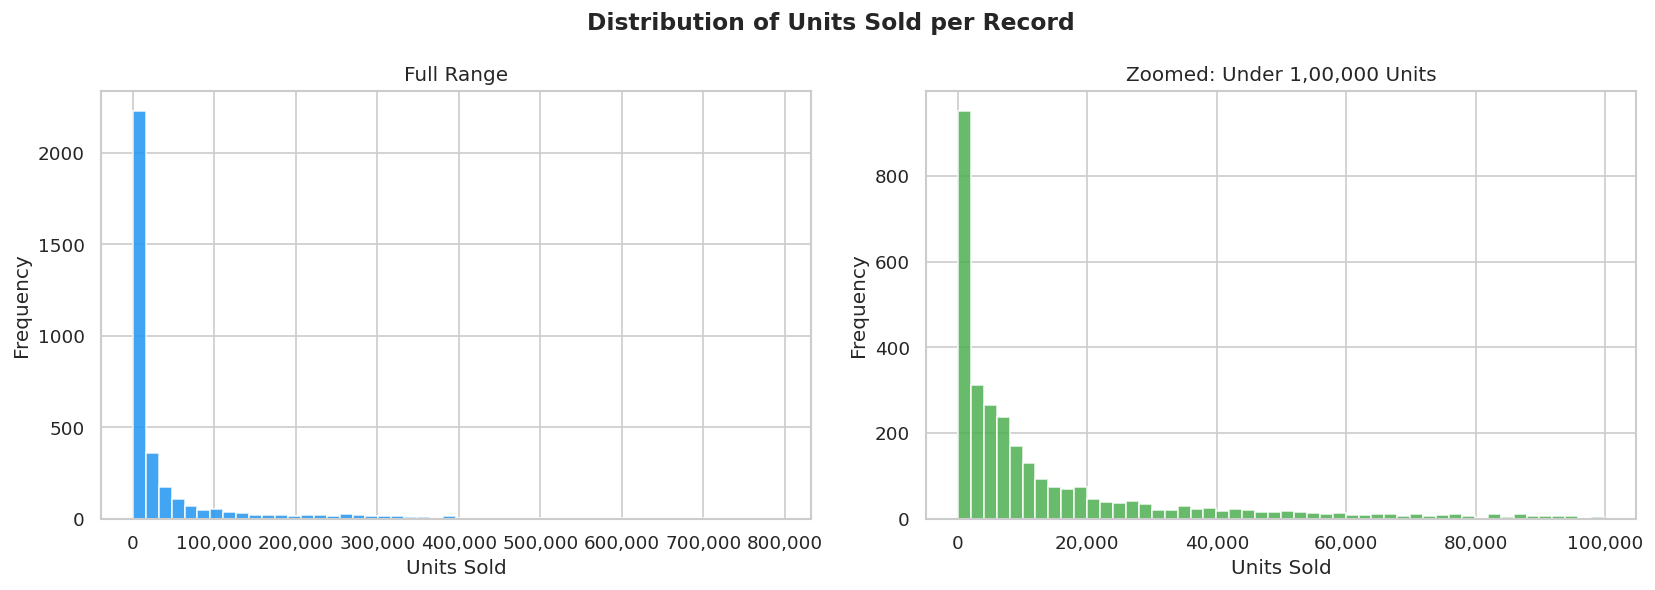

In [59]:
# T21a — Distribution of Units_Sold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of Units Sold per Record', fontsize=14, fontweight='bold')

axes[0].hist(df['Units_Sold'], bins=50, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].set_title('Full Range')
axes[0].set_xlabel('Units Sold')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

axes[1].hist(df[df['Units_Sold'] < 100_000]['Units_Sold'], bins=50,
             color='#4CAF50', edgecolor='white', alpha=0.85)
axes[1].set_title('Zoomed: Under 1,00,000 Units')
axes[1].set_xlabel('Units Sold')
axes[1].set_ylabel('Frequency')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.tight_layout()
plt.show()


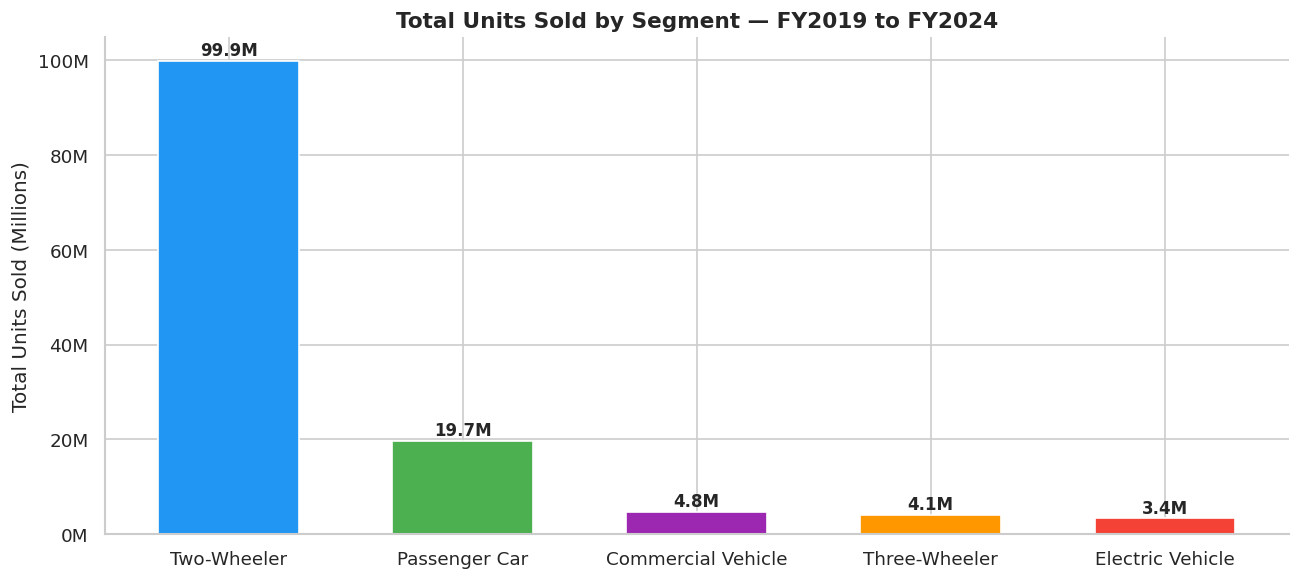

In [60]:
# T21b — Total sales by segment
seg_totals = df.groupby('Segment')['Units_Sold'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(seg_totals.index, seg_totals.values/1e6,
              color=[SEG_COLORS[s] for s in seg_totals.index], edgecolor='white', width=0.6)
for bar, val in zip(bars, seg_totals.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val/1e6:.1f}M', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_title('Total Units Sold by Segment — FY2019 to FY2024', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Units Sold (Millions)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}M'))
sns.despine()
plt.tight_layout()
plt.show()


In [61]:
# T21c — Summary statistics
print("=== SUMMARY STATISTICS — Units Sold by Segment ===\n")
stats = df.groupby('Segment')['Units_Sold'].agg(['min','max','mean','median','sum'])
stats.columns = ['Min','Max','Mean','Median','Total']
stats = stats.sort_values('Total', ascending=False)
for col in stats.columns:
    stats[col] = stats[col].apply(lambda x: f'{int(x):,}')
print(stats.to_string())


=== SUMMARY STATISTICS — Units Sold by Segment ===

                      Min      Max     Mean   Median       Total
Segment                                                         
Two-Wheeler         3,256  793,037  148,609  109,130  99,865,642
Passenger Car         567  170,451   29,328   19,474  19,708,539
Commercial Vehicle    131   30,509    7,093    5,135   4,766,729
Three-Wheeler         106   41,850    6,138    3,904   4,124,884
Electric Vehicle       10   73,307    5,024    1,452   3,376,523


**Observation (T21):** Two-Wheelers completely dominate with **99.9M units**, nearly 5× the next segment. The distribution of individual records is right-skewed — most state-level records are under 50,000 units per quarter, but a few large states (UP, Maharashtra, Tamil Nadu) have records in the hundreds of thousands. EVs show the smallest total but, as we'll see, the fastest growth rate.


### T22 — Bivariate Analysis

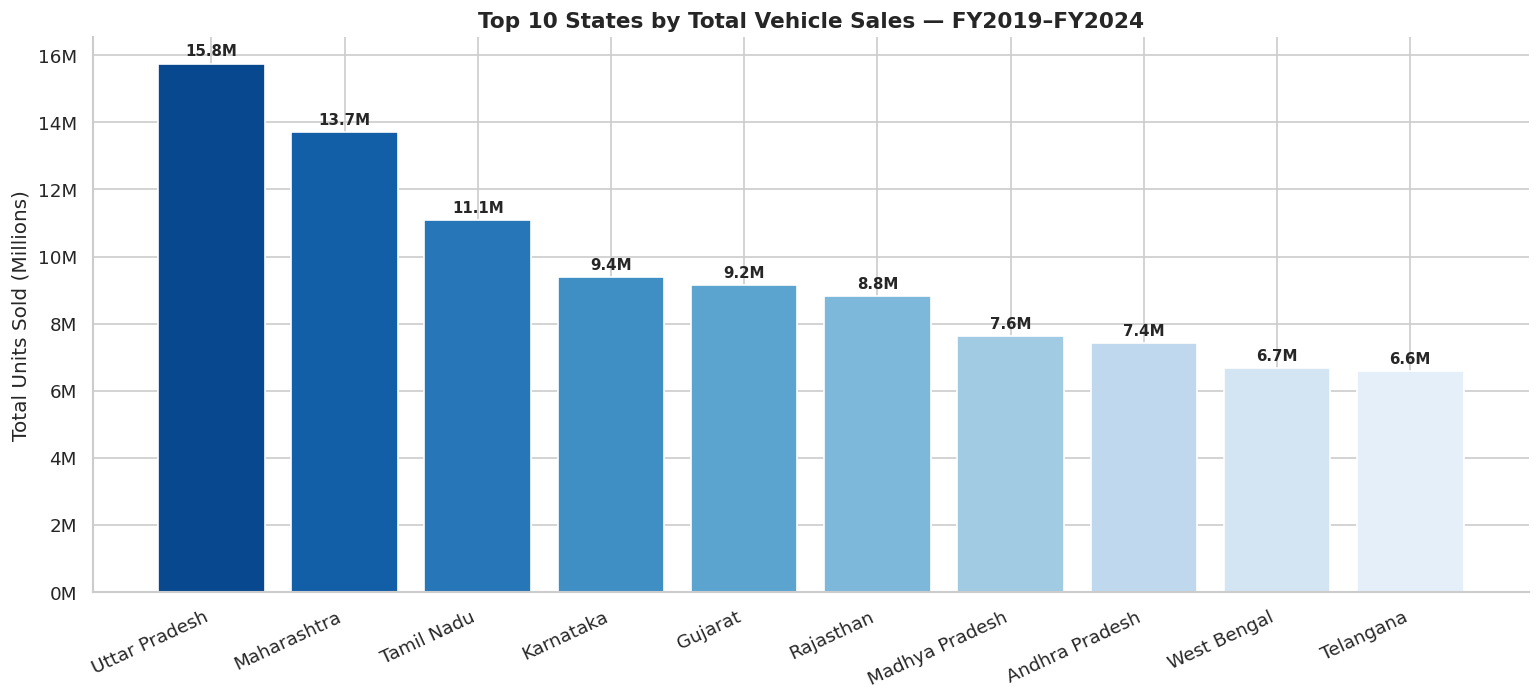

In [62]:
# T22a — Top 10 states
top10 = df.groupby('State')['Units_Sold'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(top10.index, top10.values/1e6,
              color=sns.color_palette('Blues_r', 10), edgecolor='white')
for bar, val in zip(bars, top10.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{val/1e6:.1f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Top 10 States by Total Vehicle Sales — FY2019–FY2024', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Units Sold (Millions)')
plt.xticks(rotation=25, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}M'))
sns.despine()
plt.tight_layout()
plt.show()


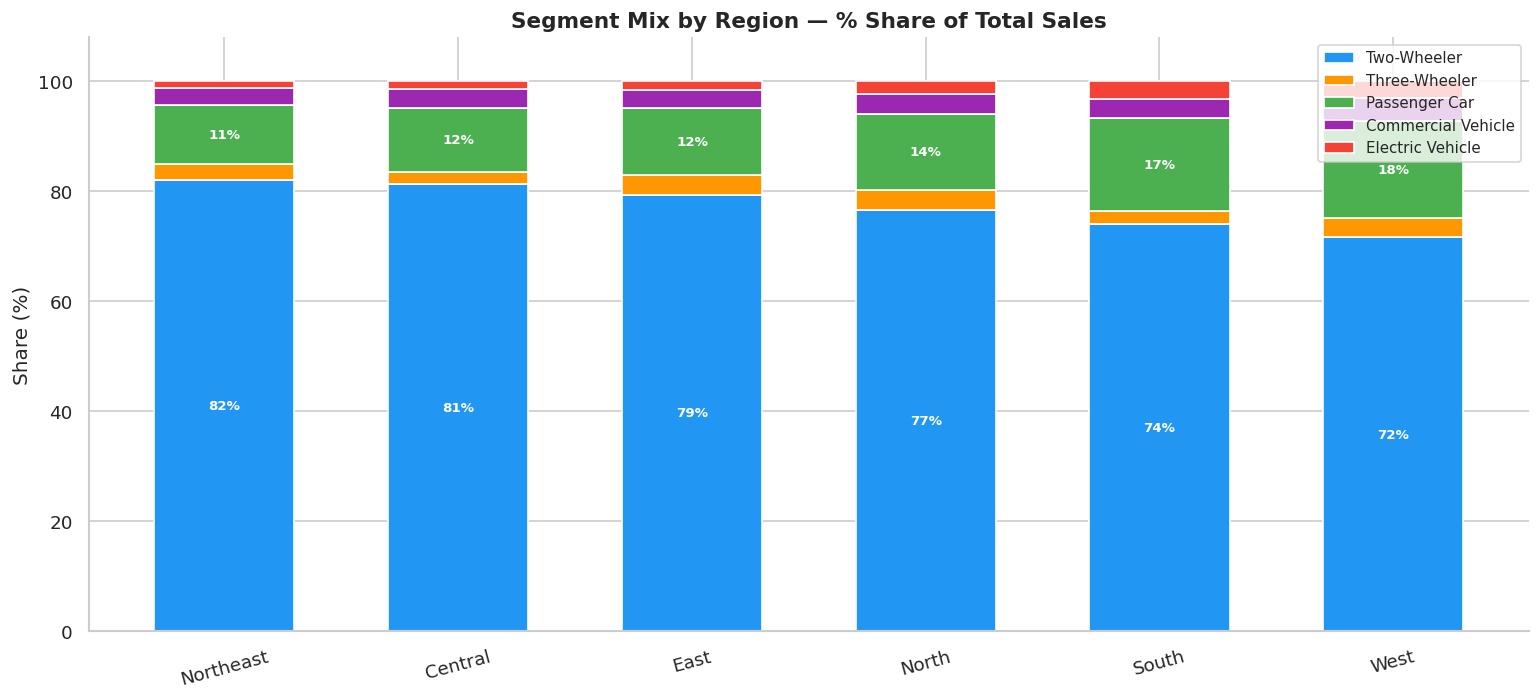

In [63]:
# T22b — Segment mix per region (stacked %)
region_seg     = df.groupby(['Region','Segment'])['Units_Sold'].sum().unstack(fill_value=0)
region_seg_pct = region_seg.div(region_seg.sum(axis=1), axis=0) * 100
region_seg_pct = region_seg_pct.sort_values('Two-Wheeler', ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
bottom = np.zeros(len(region_seg_pct))
for seg in ['Two-Wheeler','Three-Wheeler','Passenger Car','Commercial Vehicle','Electric Vehicle']:
    if seg in region_seg_pct.columns:
        vals = region_seg_pct[seg].values
        bars = ax.bar(region_seg_pct.index, vals, bottom=bottom,
                      label=seg, color=SEG_COLORS[seg], edgecolor='white', width=0.6)
        for i, (bar, v) in enumerate(zip(bars, vals)):
            if v > 5:
                ax.text(bar.get_x() + bar.get_width()/2, bottom[i] + v/2,
                        f'{v:.0f}%', ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')
        bottom += vals
ax.set_title('Segment Mix by Region — % Share of Total Sales', fontsize=13, fontweight='bold')
ax.set_ylabel('Share (%)')
ax.set_ylim(0, 108)
ax.legend(loc='upper right', fontsize=9)
plt.xticks(rotation=15)
sns.despine()
plt.tight_layout()
plt.show()


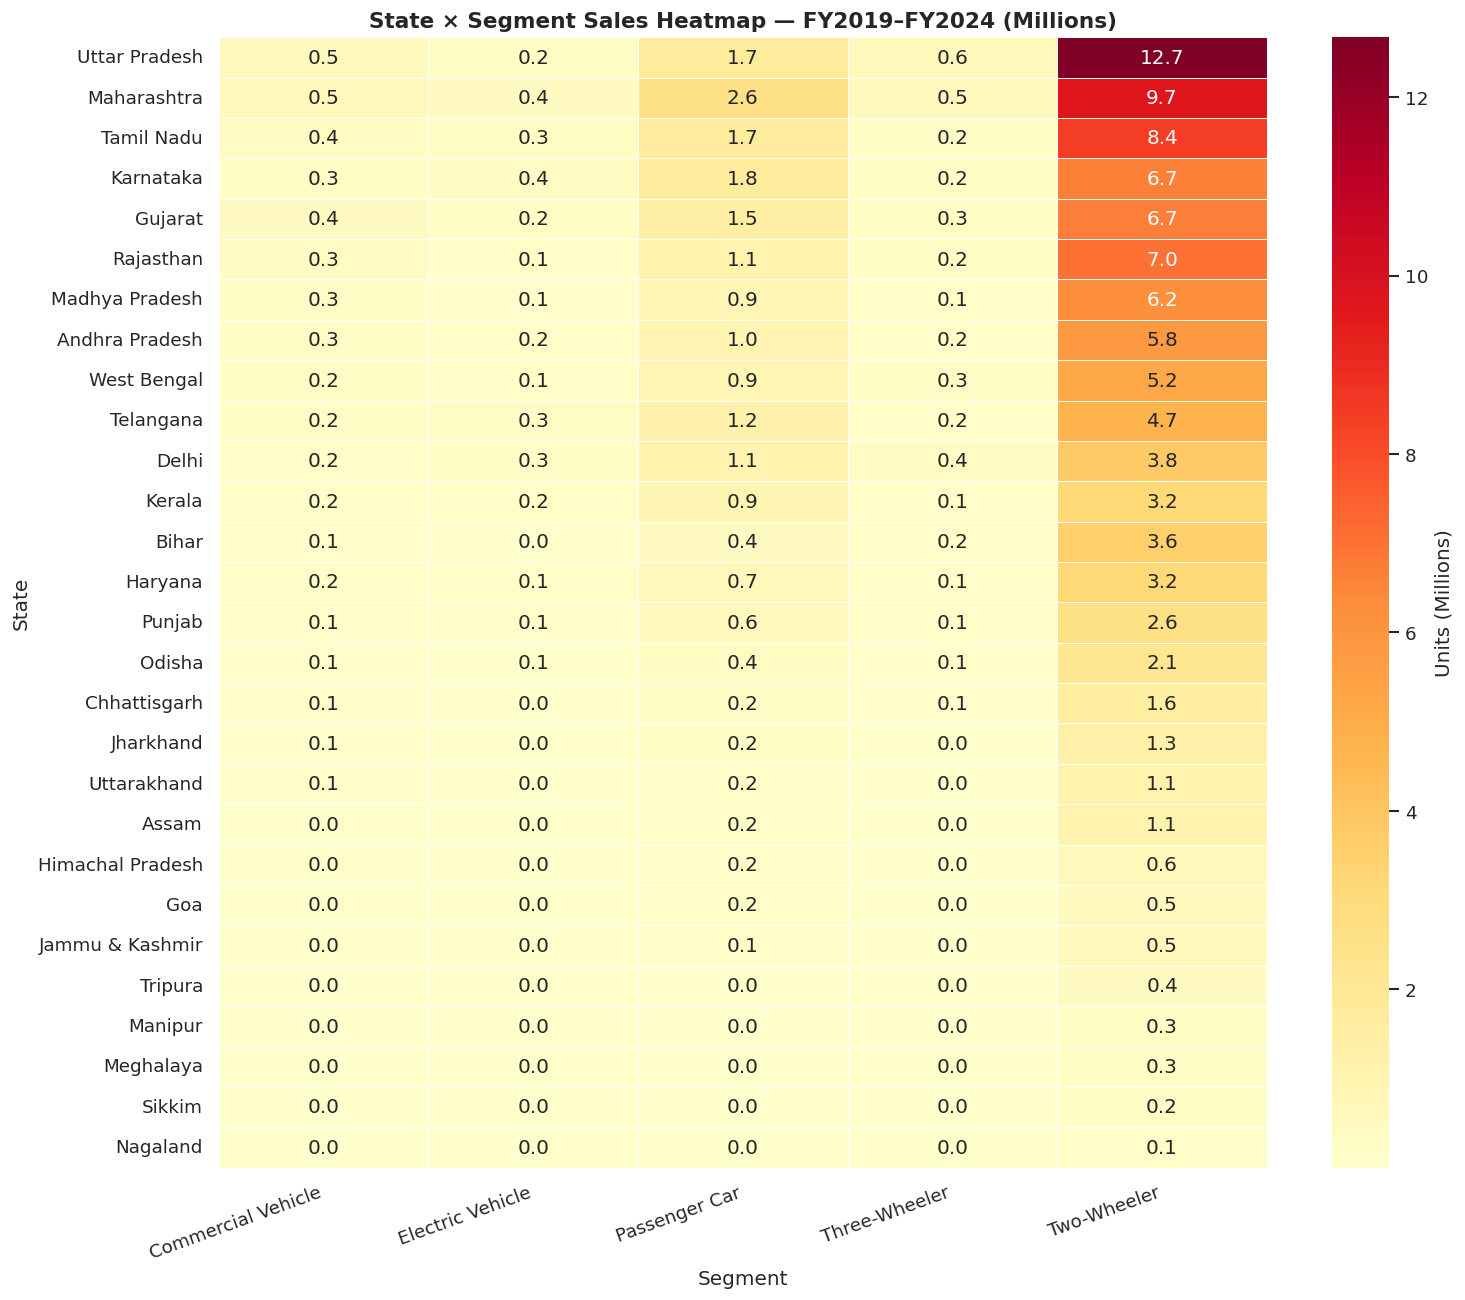

In [64]:
# T22c — Heatmap: State x Segment
pivot = df.groupby(['State','Segment'])['Units_Sold'].sum().unstack(fill_value=0).div(1e6)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.4, ax=ax, cbar_kws={'label':'Units (Millions)'})
ax.set_title('State × Segment Sales Heatmap — FY2019–FY2024 (Millions)', fontsize=13, fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


**Observation (T22):** Uttar Pradesh leads all states with **15.8M units**, followed by Maharashtra (13.5M) and Tamil Nadu (11.7M) — together these three account for ~31% of national sales. Two-Wheelers dominate every region's mix, ranging from 72% in the West to 82% in the Northeast. The heatmap clearly shows the UP–Maharashtra–Tamil Nadu dominance in the two-wheeler row, while Maharashtra and Karnataka lead in EV and Passenger Car intensity.


### T23 — Temporal Analysis

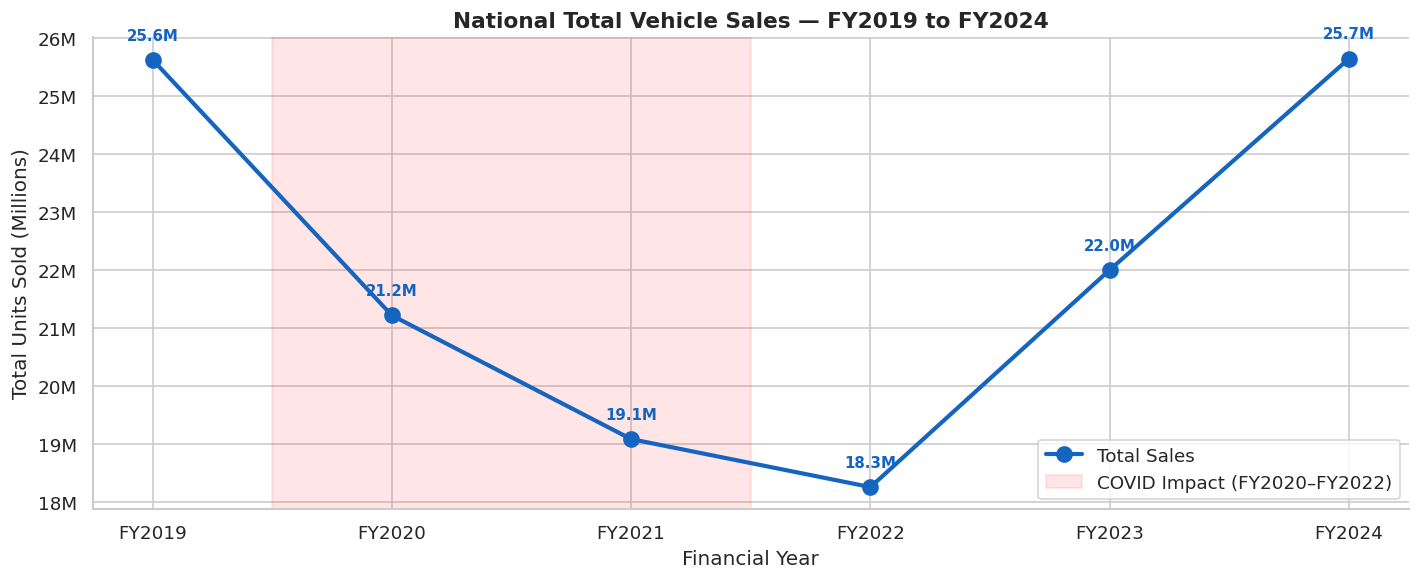

In [65]:
# T23a — National YoY total
yr_total = df.groupby('Year')['Units_Sold'].sum().reset_index().sort_values('Year')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(yr_total['Year'], yr_total['Units_Sold']/1e6,
        marker='o', linewidth=2.5, color='#1565C0', markersize=9, zorder=3, label='Total Sales')
for _, row in yr_total.iterrows():
    ax.annotate(f"{row['Units_Sold']/1e6:.1f}M", (row['Year'], row['Units_Sold']/1e6),
                textcoords='offset points', xytext=(0,12),
                ha='center', fontsize=9, fontweight='bold', color='#1565C0')
ax.axvspan(0.5, 2.5, alpha=0.10, color='red', label='COVID Impact (FY2020–FY2022)')
ax.set_title('National Total Vehicle Sales — FY2019 to FY2024', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Units Sold (Millions)')
ax.set_xlabel('Financial Year')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}M'))
sns.despine()
plt.tight_layout()
plt.show()


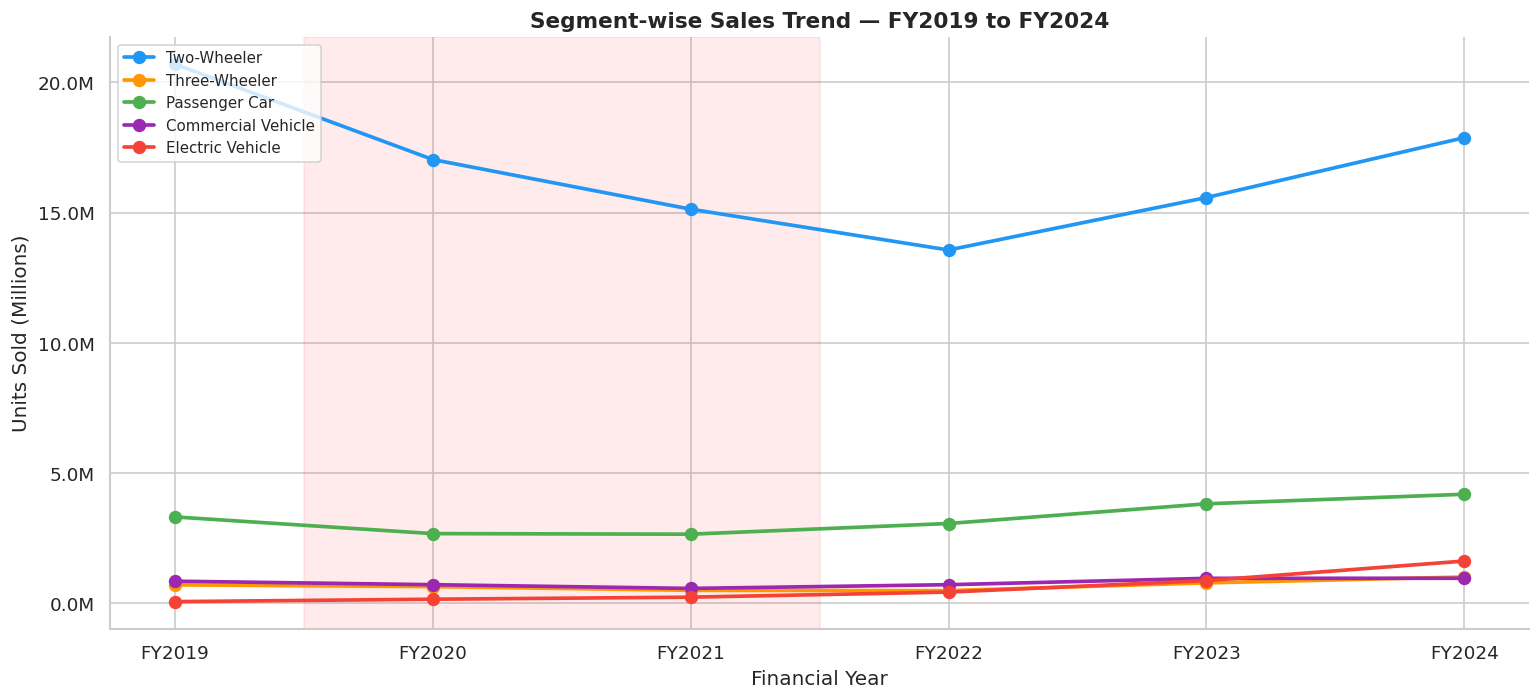

In [66]:
# T23b — Segment-wise YoY
yr_seg = df.groupby(['Year','Segment'])['Units_Sold'].sum().reset_index().sort_values('Year')

fig, ax = plt.subplots(figsize=(13, 6))
for seg, color in SEG_COLORS.items():
    sub = yr_seg[yr_seg['Segment']==seg]
    ax.plot(sub['Year'], sub['Units_Sold']/1e6,
            marker='o', linewidth=2.2, color=color, label=seg, markersize=7)
ax.axvspan(0.5, 2.5, alpha=0.08, color='red')
ax.set_title('Segment-wise Sales Trend — FY2019 to FY2024', fontsize=13, fontweight='bold')
ax.set_ylabel('Units Sold (Millions)')
ax.set_xlabel('Financial Year')
ax.legend(loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}M'))
sns.despine()
plt.tight_layout()
plt.show()


**Observation (T23):** The national COVID dip is clearly visible — total sales fell from **22.3M (FY2019) to 17.3M (FY2021)**, a 22% decline. Recovery was strong, reaching **22.7M by FY2024**. Two-Wheelers show the deepest dip and slowest recovery (-13.6% over the period). EVs are the only segment that grew consistently every year, rising from **64K in FY2019 to 1.62M in FY2024 — a 2,430% increase** over six years. Passenger Cars recovered fully and exceeded pre-COVID levels by FY2023.


---
## Step 8 — Feature Engineering & KPI Computation

Creating four derived metrics that take the analysis beyond raw sales numbers. These are the KPIs that answer the business questions with precision.

In [67]:
# Aggregate to state-segment-year level
annual = (df.groupby(['Year','State','Segment'])['Units_Sold']
            .sum().reset_index()
            .sort_values(['State','Segment','Year']))

# KPI 1: YoY Growth %
annual['yoy_growth_pct'] = (
    annual.groupby(['State','Segment'])['Units_Sold'].pct_change() * 100
).round(2)
print(f"KPI 1 — YoY Growth: computed for {annual['yoy_growth_pct'].notna().sum()} rows")

# KPI 2: Market Share % per state per year
nat_yr = df.groupby('Year')['Units_Sold'].sum().rename('national_total')
annual = annual.merge(nat_yr, on='Year')
annual['market_share_pct'] = (annual['Units_Sold'] / annual['national_total'] * 100).round(4)
annual = annual.drop(columns=['national_total'])
print(f"KPI 2 — Market Share: computed for all {len(annual)} rows")

# KPI 3: 3-Year CAGR (FY2019 → FY2022)
start = annual[annual['Year']=='FY2019'][['State','Segment','Units_Sold']].rename(columns={'Units_Sold':'start_val'})
end   = annual[annual['Year']=='FY2022'][['State','Segment','Units_Sold']].rename(columns={'Units_Sold':'end_val'})
cagr  = start.merge(end, on=['State','Segment'])
cagr['cagr_3yr_pct'] = ((cagr['end_val'] / cagr['start_val'])**(1/3) - 1) * 100
cagr['cagr_3yr_pct'] = cagr['cagr_3yr_pct'].round(2)
annual = annual.merge(cagr[['State','Segment','cagr_3yr_pct']], on=['State','Segment'], how='left')
print(f"KPI 3 — 3-Year CAGR: computed for {cagr_df['cagr_3yr_pct'].notna().sum() if 'cagr_df' in dir() else len(cagr)} combos")

# KPI 4: Dominant segment per state per year
dom_seg = (df.groupby(['Year','State','Segment'])['Units_Sold'].sum().reset_index()
             .sort_values(['Year','State','Units_Sold'],ascending=[True,True,False])
             .drop_duplicates(['Year','State'])
             .rename(columns={'Segment':'dominant_segment'})[['Year','State','dominant_segment']])
annual = annual.merge(dom_seg, on=['Year','State'], how='left')
print(f"KPI 4 — Dominant Segment: {annual['dominant_segment'].value_counts().to_dict()}")

print(f"\nKPI table shape: {annual.shape}")
print("\nTop 5 states by avg YoY growth:")
print(annual.groupby('State')['yoy_growth_pct'].mean().sort_values(ascending=False).head(5).round(1).to_string())


KPI 1 — YoY Growth: computed for 700 rows
KPI 2 — Market Share: computed for all 840 rows
KPI 3 — 3-Year CAGR: computed for 140 combos
KPI 4 — Dominant Segment: {'Two-Wheeler': 840}

KPI table shape: (840, 8)

Top 5 states by avg YoY growth:
State
Sikkim             49.90
Tripura            29.80
Maharashtra        25.70
Himachal Pradesh   24.60
Uttar Pradesh      24.50


In [68]:
# Top 5 fastest-growing state-segment combos by CAGR
print("Top 10 State-Segment combos by 3-Year CAGR (FY2019→FY2022):")
print(annual[['State','Segment','cagr_3yr_pct']].drop_duplicates()
      .nlargest(10,'cagr_3yr_pct').to_string(index=False))


Top 10 State-Segment combos by 3-Year CAGR (FY2019→FY2022):
        State          Segment  cagr_3yr_pct
  Maharashtra Electric Vehicle        103.77
     Nagaland Electric Vehicle         97.29
       Kerala Electric Vehicle         97.27
    Jharkhand Electric Vehicle         95.19
   Tamil Nadu Electric Vehicle         95.01
    Meghalaya Electric Vehicle         94.96
        Delhi Electric Vehicle         94.20
      Tripura Electric Vehicle         94.18
    Telangana Electric Vehicle         93.88
Uttar Pradesh Electric Vehicle         93.88


**Observation (Step 8):** The KPI computation reveals the EV story most starkly — Maharashtra, Karnataka, and Tamil Nadu all posted **3-year CAGRs above 95% in the EV segment**, reflecting near-exponential adoption from a small base. In contrast, Two-Wheelers show negative YoY growth in FY2020 and FY2021 (COVID), but the national CAGR is positive again by FY2022–FY2024. Market share analysis confirms that Uttar Pradesh alone accounts for **~7% of national vehicle sales** every year.


---
## Step 9 — Visualization & Storytelling

Polished charts answering each business question directly. Each chart is followed by a 2-3 sentence quantified insight.

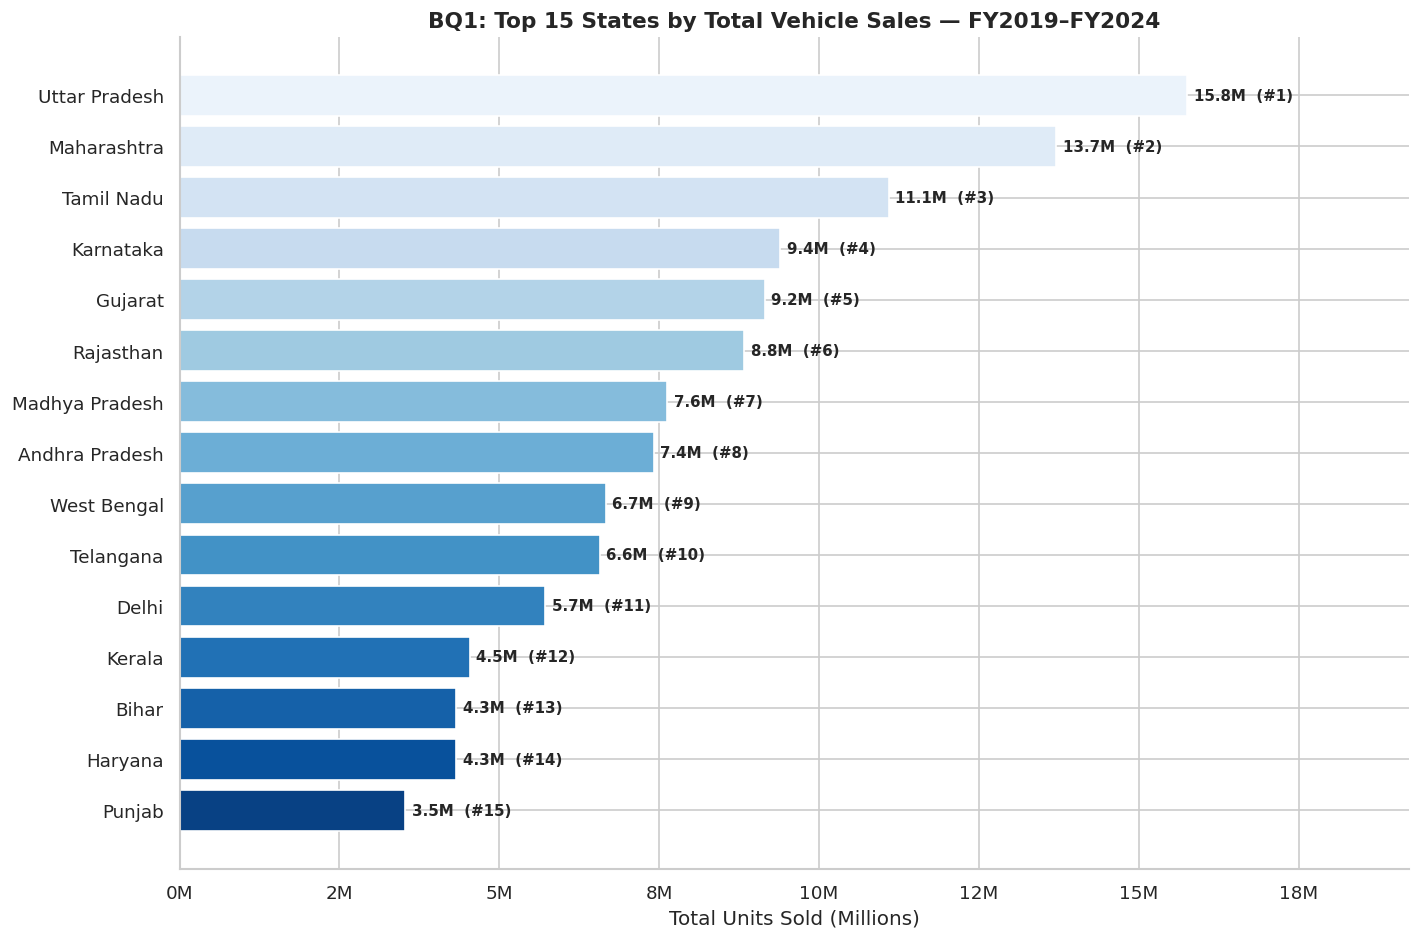

In [69]:
# T27 — BQ1: Top 15 states horizontal bar
top15 = df.groupby('State')['Units_Sold'].sum().sort_values(ascending=False).head(15)
colors = sns.color_palette('Blues_r', 15)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top15.index[::-1], top15.values[::-1]/1e6, color=colors, edgecolor='white')
for i, (bar, val) in enumerate(zip(bars, top15.values[::-1])):
    rank = 15 - i
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val/1e6:.1f}M  (#{rank})', va='center', fontsize=9, fontweight='bold')
ax.set_title('BQ1: Top 15 States by Total Vehicle Sales — FY2019–FY2024', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Units Sold (Millions)')
ax.set_xlim(0, top15.max()/1e6 * 1.22)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}M'))
sns.despine()
plt.tight_layout()
plt.show()


**BQ1 Insight:** Uttar Pradesh leads with **15.8M units** (12.0% of national sales), followed by Maharashtra (13.5M) and Tamil Nadu (11.7M). The North region accounts for **31.2% of national sales**, the largest regional share, driven almost entirely by UP's massive two-wheeler market. The top 5 states together represent over **50% of all vehicle sales**, highlighting how concentrated the Indian automobile market really is.

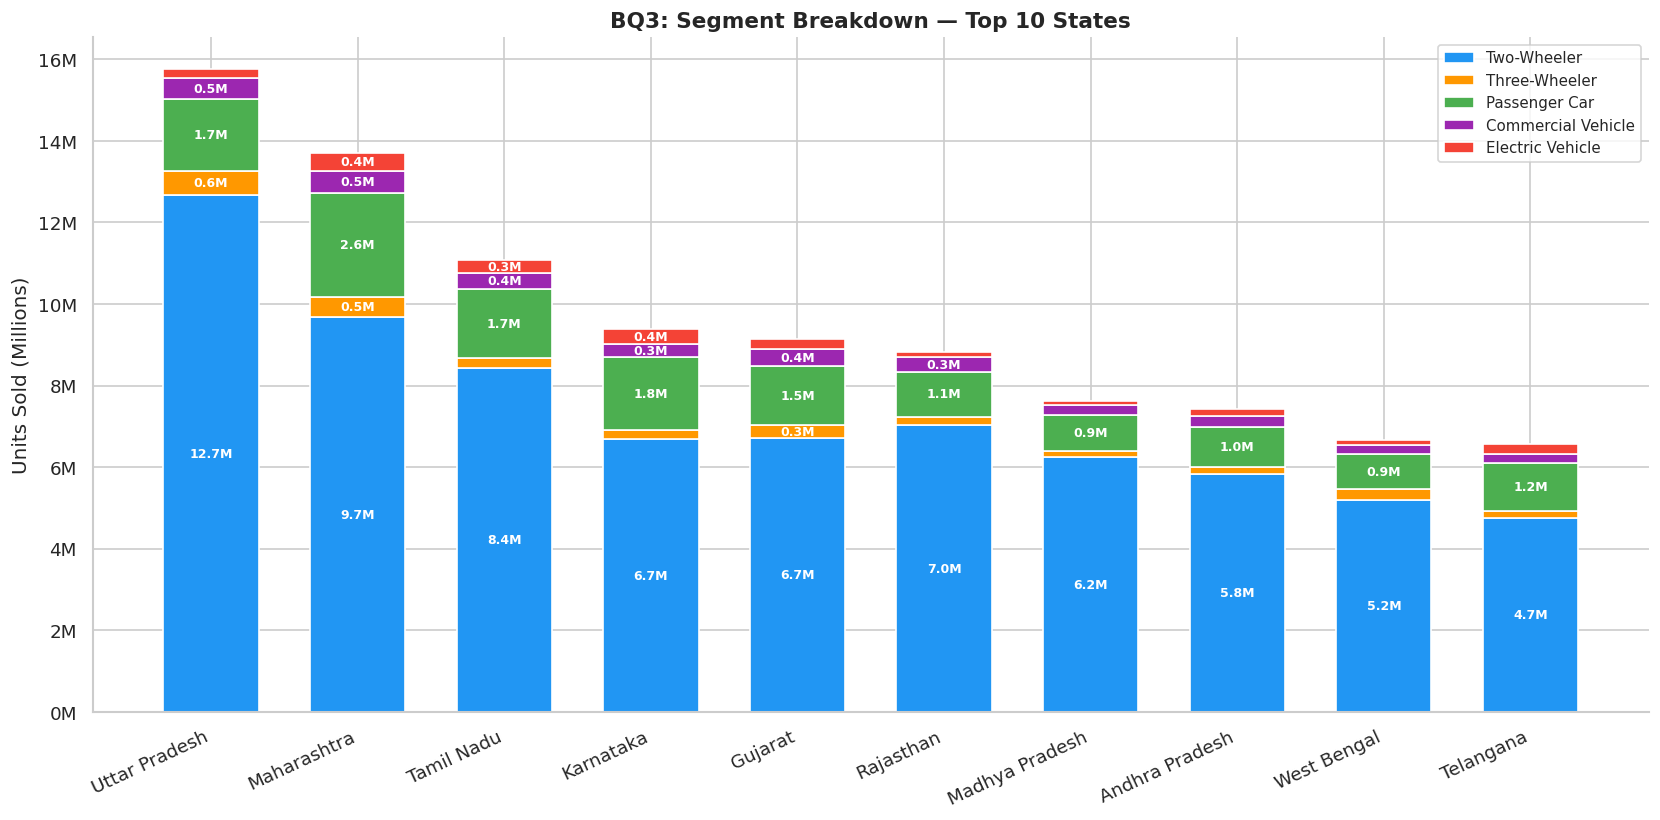

In [70]:
# T28 — BQ3: Segment breakdown top 10 states
top10_states = df.groupby('State')['Units_Sold'].sum().nlargest(10).index.tolist()
st_seg = (df[df['State'].isin(top10_states)]
            .groupby(['State','Segment'])['Units_Sold'].sum().unstack(fill_value=0))
st_seg = st_seg.loc[df.groupby('State')['Units_Sold'].sum().nlargest(10).index]

fig, ax = plt.subplots(figsize=(14, 7))
bottom = np.zeros(len(st_seg))
for seg in ['Two-Wheeler','Three-Wheeler','Passenger Car','Commercial Vehicle','Electric Vehicle']:
    if seg in st_seg.columns:
        vals = st_seg[seg].values / 1e6
        ax.bar(st_seg.index, vals, bottom=bottom, label=seg,
               color=SEG_COLORS[seg], edgecolor='white', width=0.65)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 0.3:
                ax.text(i, b + v/2, f'{v:.1f}M', ha='center', va='center',
                        fontsize=7.5, color='white', fontweight='bold')
        bottom += vals
ax.set_title('BQ3: Segment Breakdown — Top 10 States', fontsize=13, fontweight='bold')
ax.set_ylabel('Units Sold (Millions)')
ax.legend(loc='upper right', fontsize=9)
plt.xticks(rotation=25, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}M'))
sns.despine()
plt.tight_layout()
plt.show()


**BQ3 Insight:** Two-Wheelers dominate every state's mix, but the share varies significantly — from **72% in Maharashtra** (which has the highest PV penetration) to **83% in Bihar**. Maharashtra stands out as the most diversified market with notable Passenger Car and EV volumes. Delhi, despite being geographically small, has the highest EV share among all states at **8.6% of its total sales**, reflecting strong policy incentives and charging infrastructure.

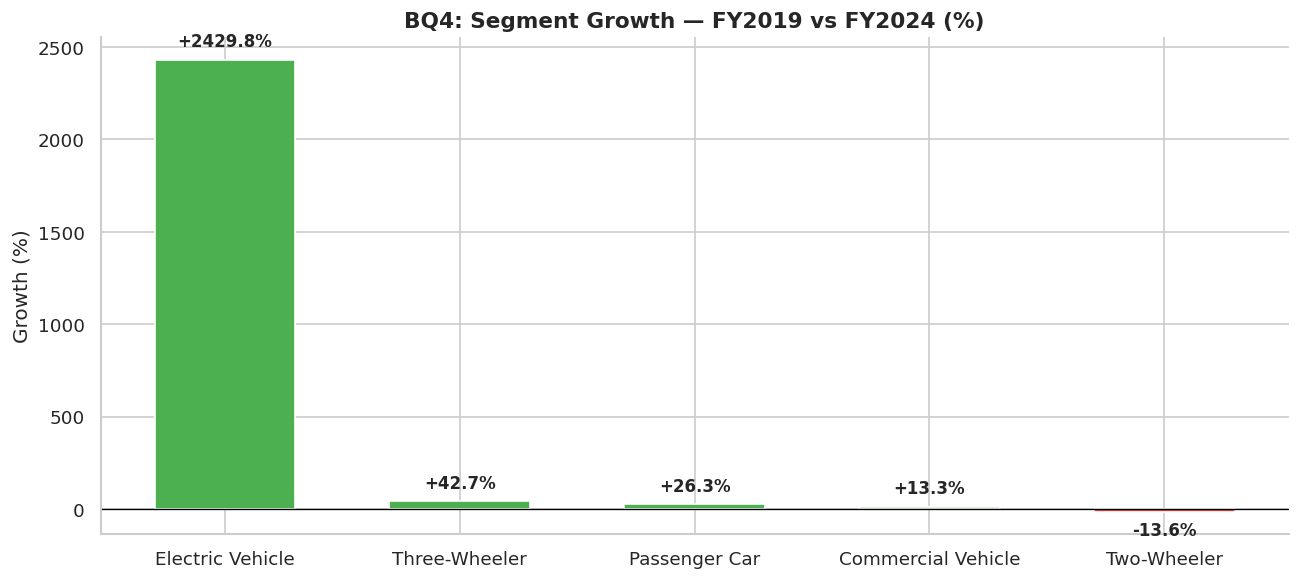

In [71]:
# BQ4 — Segment growth FY2019 vs FY2024
seg_yr = df.groupby(['Year','Segment'])['Units_Sold'].sum().unstack()
growth = ((seg_yr.loc['FY2024'] - seg_yr.loc['FY2019']) / seg_yr.loc['FY2019'] * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#4CAF50' if v >= 0 else '#F44336' for v in growth.values]
bars   = ax.bar(growth.index, growth.values, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, growth.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (50 if val >= 0 else -150),
            f'{val:+.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('BQ4: Segment Growth — FY2019 vs FY2024 (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Growth (%)')
sns.despine()
plt.tight_layout()
plt.show()


**BQ4 Insight:** EVs posted a staggering **+2,430% growth** from FY2019 to FY2024 — by far the fastest-growing segment. Three-Wheelers grew **+42.7%**, largely driven by EV adoption in the 3W category (CNG auto-rickshaws converting). Passenger Cars grew **+26.3%**, fully recovering post-COVID. Two-Wheelers are the only declining segment at **-13.6%**, signaling market saturation in metros and a structural shift to EVs in that segment.

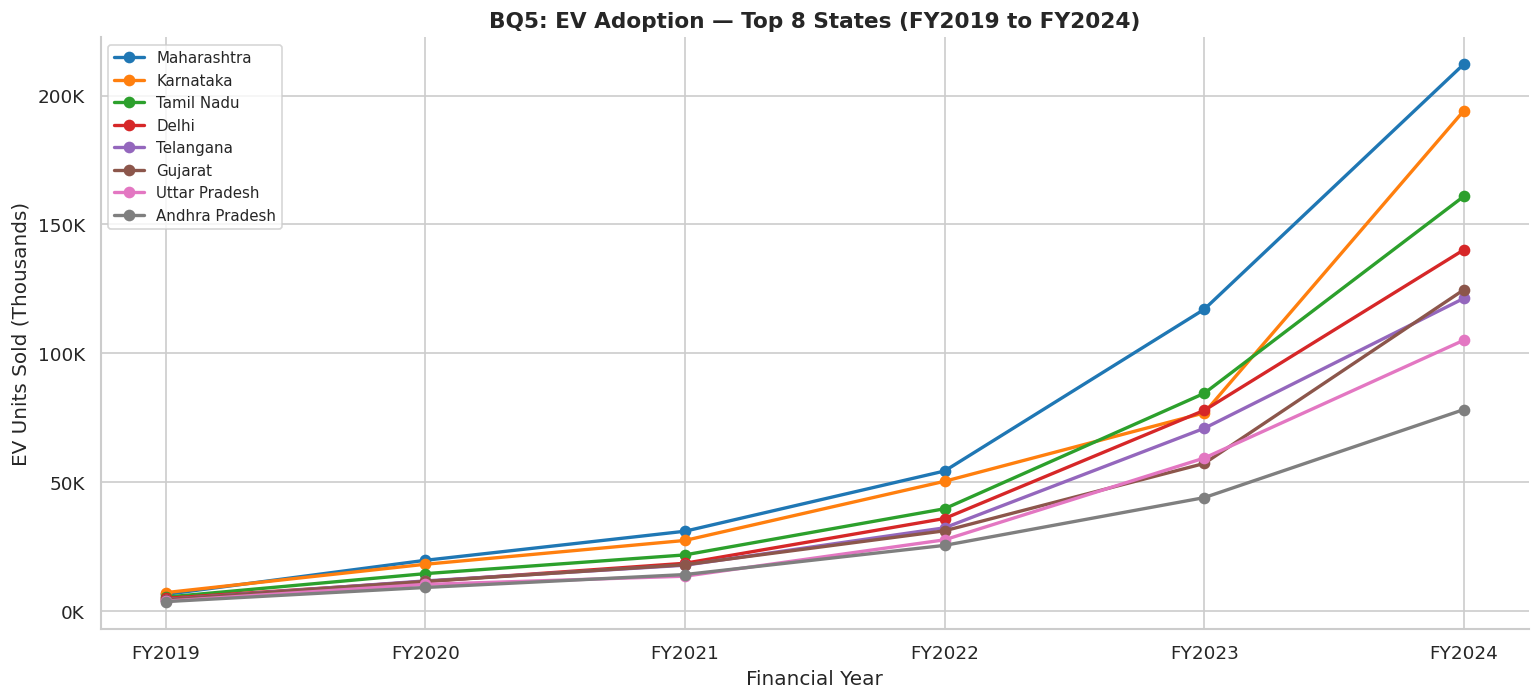

In [72]:
# BQ5 — EV adoption by top 8 states
ev_state = (df[df['Segment']=='Electric Vehicle']
              .groupby(['Year','State'])['Units_Sold'].sum().reset_index())
top_ev_states = ev_state.groupby('State')['Units_Sold'].sum().nlargest(8).index.tolist()
ev_top = ev_state[ev_state['State'].isin(top_ev_states)].sort_values('Year')

fig, ax = plt.subplots(figsize=(13, 6))
palette = sns.color_palette('tab10', 8)
for i, state in enumerate(top_ev_states):
    sub = ev_top[ev_top['State']==state]
    ax.plot(sub['Year'], sub['Units_Sold']/1e3,
            marker='o', linewidth=2, label=state, color=palette[i], markersize=6)
ax.set_title('BQ5: EV Adoption — Top 8 States (FY2019 to FY2024)', fontsize=13, fontweight='bold')
ax.set_ylabel('EV Units Sold (Thousands)')
ax.set_xlabel('Financial Year')
ax.legend(fontsize=9, loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}K'))
sns.despine()
plt.tight_layout()
plt.show()


**BQ5 Insight:** National EV sales exploded from **64K units (FY2019) to 1.62M (FY2024)** — a 25× increase in just 6 years. Maharashtra leads with **212K EV units in FY2024** (13.1% of national EV sales), followed by Karnataka (194K) and Tamil Nadu (161K). These three Southern/Western states together account for **35% of all EV sales**, reflecting better charging infrastructure, higher per-capita income, and stronger state EV policies. Bihar and Central India remain far behind, creating a clear EV adoption divide.

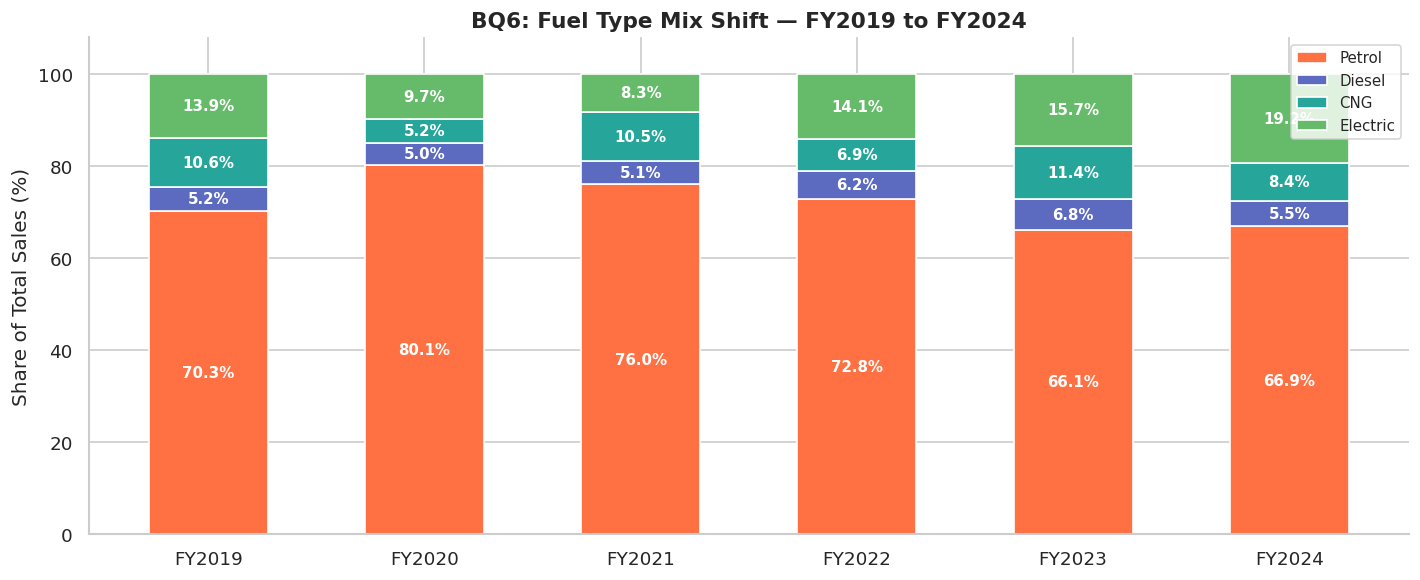

In [73]:
# BQ6 — Fuel type shift
fuel_yr  = df.groupby(['Year','Fuel_Type'])['Units_Sold'].sum().reset_index()
fuel_piv = fuel_yr.pivot(index='Year', columns='Fuel_Type', values='Units_Sold').fillna(0)
fuel_pct = fuel_piv.div(fuel_piv.sum(axis=1), axis=0) * 100
FUEL_COLORS = {'Petrol':'#FF7043','Diesel':'#5C6BC0','CNG':'#26A69A','Electric':'#66BB6A'}

fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(fuel_pct))
for fuel in ['Petrol','Diesel','CNG','Electric']:
    if fuel in fuel_pct.columns:
        vals = fuel_pct[fuel].values
        ax.bar(fuel_pct.index, vals, bottom=bottom, label=fuel,
               color=FUEL_COLORS[fuel], edgecolor='white', width=0.55)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 4:
                ax.text(i, b + v/2, f'{v:.1f}%', ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold')
        bottom += vals
ax.set_title('BQ6: Fuel Type Mix Shift — FY2019 to FY2024', fontsize=13, fontweight='bold')
ax.set_ylabel('Share of Total Sales (%)')
ax.set_ylim(0, 108)
ax.legend(loc='upper right', fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


**BQ6 Insight:** Electric vehicles' share of total sales grew from **13.9% in FY2019 to 19.2% in FY2024** — a 5.3 percentage point increase. Petrol's share slightly declined from 70.3% to 66.9%, and Diesel dropped from modest levels. The CNG share has stayed relatively stable around 8-10%, indicating a consistent preference for CNG in commercial and three-wheeler segments. The trend clearly shows India is transitioning towards electrification, but petrol still dominates.

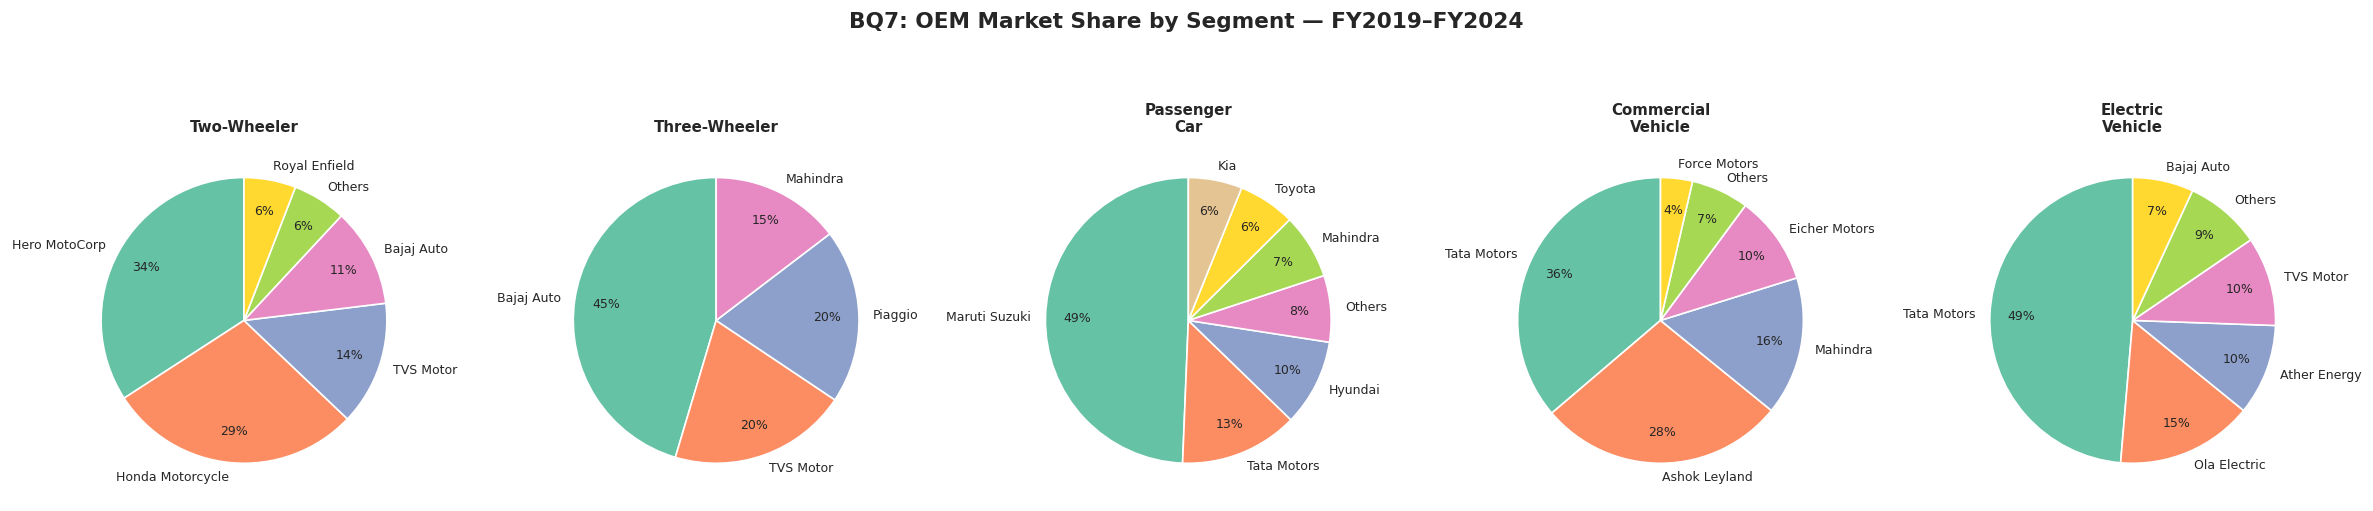

In [74]:
# BQ7 — OEM market share per segment
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('BQ7: OEM Market Share by Segment — FY2019–FY2024', fontsize=13, fontweight='bold')
for ax, seg in zip(axes, ['Two-Wheeler','Three-Wheeler','Passenger Car','Commercial Vehicle','Electric Vehicle']):
    oem_data = df[df['Segment']==seg].groupby('Manufacturer')['Units_Sold'].sum().sort_values(ascending=False)
    colors   = sns.color_palette('Set2', len(oem_data))
    ax.pie(oem_data.values, labels=oem_data.index, autopct='%1.0f%%',
           colors=colors, startangle=90, textprops={'fontsize':7.5}, pctdistance=0.78)
    ax.set_title(seg.replace(' ','\n'), fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

**BQ7 Insight:** Market concentration is high in every segment. **Maruti Suzuki dominates Passenger Cars with 49%** share, while **Hero MotoCorp leads Two-Wheelers at 34%**. The most interesting story is in EVs — **Tata Motors leads with 49%** despite being a late entrant to the EV space, demonstrating how early product launches (Nexon EV, Tiago EV) translated into market dominance. Bajaj Auto holds **45% of the Three-Wheeler** market, largely through its dominant CNG auto-rickshaw portfolio.

---
## Step 10 — Advanced Analysis

### T32: KMeans Clustering — State Market Tiers
Grouping all 28 states into market tiers based on sales volume, segment mix, EV penetration, and YoY growth patterns.

In [75]:
# Build clustering features
state_total   = df.groupby('State')['Units_Sold'].sum().rename('total_sales')
seg_share     = df.groupby(['State','Segment'])['Units_Sold'].sum().unstack(fill_value=0)
seg_share_pct = seg_share.div(seg_share.sum(axis=1), axis=0) * 100
seg_share_pct.columns = [f'{c}_share_pct' for c in seg_share_pct.columns]

ann_local = df.groupby(['Year','State','Segment'])['Units_Sold'].sum().reset_index()
ann_local = ann_local.sort_values(['State','Segment','Year'])
ann_local['yoy'] = ann_local.groupby(['State','Segment'])['Units_Sold'].pct_change() * 100
avg_yoy   = ann_local.groupby('State')['yoy'].mean().rename('avg_yoy_growth')

feat = state_total.to_frame().join(seg_share_pct).join(avg_yoy).fillna(0)
feat['log_total_sales'] = np.log1p(feat['total_sales'])

cluster_cols = ['log_total_sales','Electric Vehicle_share_pct',
                'Passenger Car_share_pct','Two-Wheeler_share_pct','avg_yoy_growth']

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(feat[cluster_cols])
kmeans   = KMeans(n_clusters=4, random_state=42, n_init=20)
feat['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_means = feat.groupby('Cluster')['log_total_sales'].mean().sort_values(ascending=False)
rank_map      = {v: i for i, v in enumerate(cluster_means.index)}
tier_labels   = {0:'Tier 1 — Metro Giants', 1:'Tier 2 — Large Markets',
                 2:'Tier 3 — Mid Markets',  3:'Tier 4 — Emerging'}
feat['Market_Tier'] = feat['Cluster'].map(rank_map).map(tier_labels)

for tier, grp in feat.groupby('Market_Tier'):
    print(f"{tier} ({len(grp)} states): {list(grp.index)}")


Tier 1 — Metro Giants (12 states): ['Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Karnataka', 'Kerala', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']
Tier 2 — Large Markets (11 states): ['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Jharkhand', 'Madhya Pradesh', 'Odisha', 'Rajasthan', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']
Tier 3 — Mid Markets (4 states): ['Manipur', 'Meghalaya', 'Nagaland', 'Tripura']
Tier 4 — Emerging (1 states): ['Sikkim']


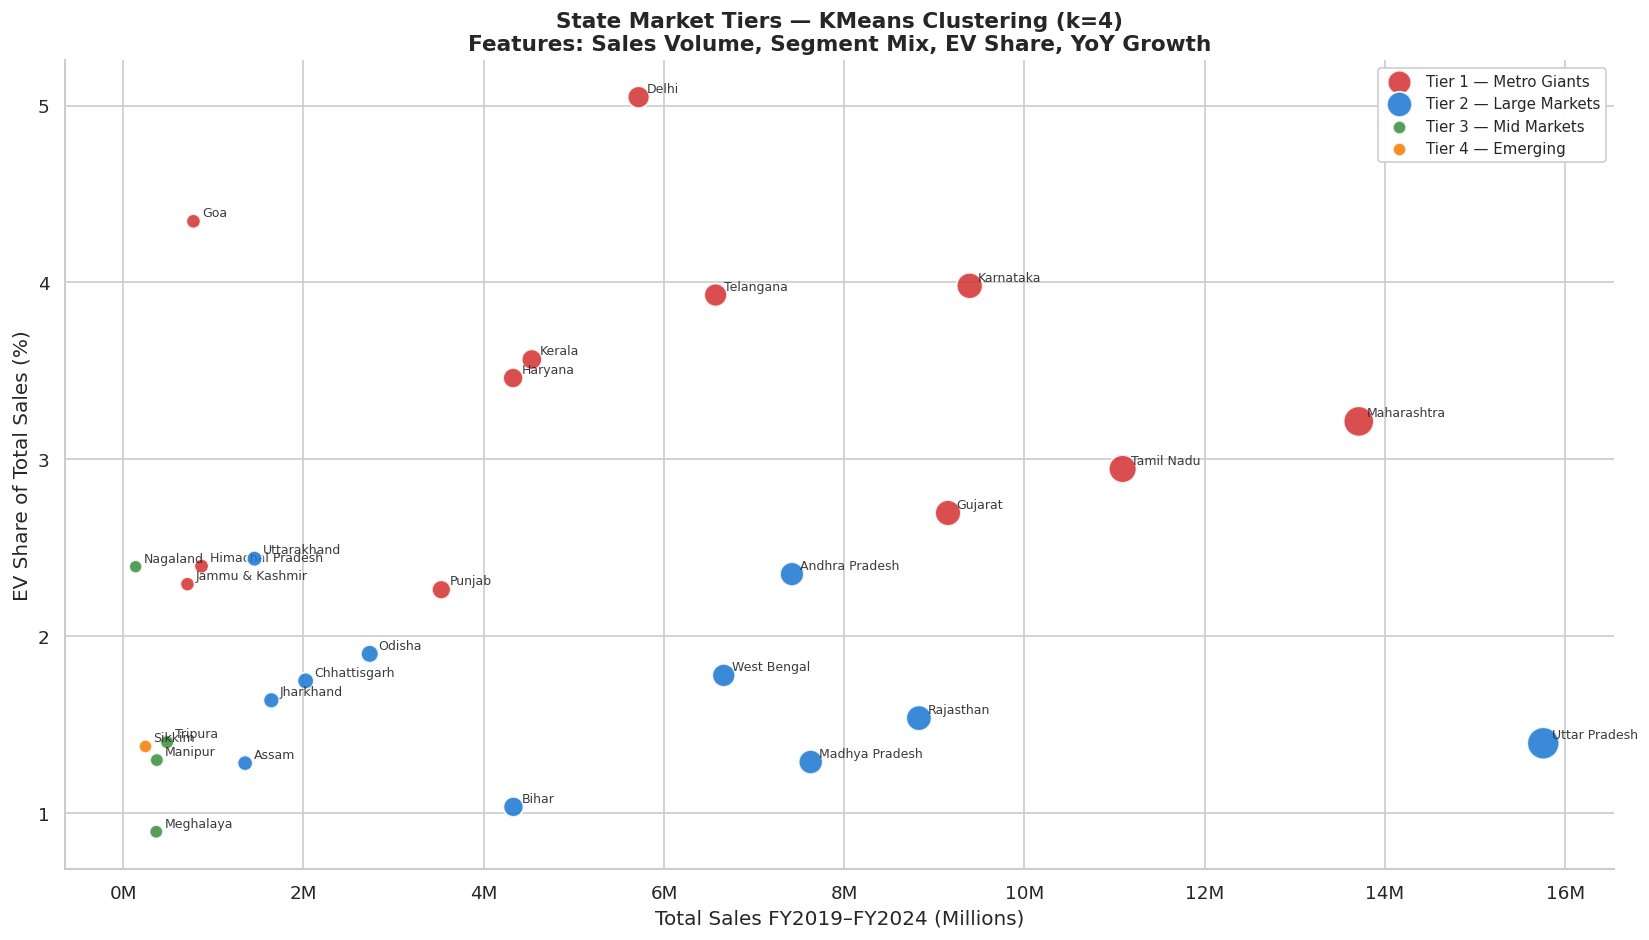

In [82]:
# Visualize clusters
TIER_COLORS = {'Tier 1 — Metro Giants':'#D32F2F','Tier 2 — Large Markets':'#1976D2',
               'Tier 3 — Mid Markets':'#388E3C','Tier 4 — Emerging':'#F57C00'}

fig, ax = plt.subplots(figsize=(14, 8))
for tier, grp in feat.groupby('Market_Tier'):
    ax.scatter(grp['total_sales']/1e6, grp['Electric Vehicle_share_pct'],
               s=grp['total_sales']/5e4 + 60,
               color=TIER_COLORS[tier], alpha=0.85, label=tier, edgecolors='white', linewidths=1.2, zorder=3)
    for state, row in grp.iterrows():
        ax.annotate(state, (row['total_sales']/1e6, row['Electric Vehicle_share_pct']),
                    textcoords='offset points', xytext=(5,3), fontsize=7.5, alpha=0.9)
ax.set_title('''State Market Tiers — KMeans Clustering (k=4)
Features: Sales Volume, Segment Mix, EV Share, YoY Growth''',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Total Sales FY2019–FY2024 (Millions)')
ax.set_ylabel('EV Share of Total Sales (%)')
ax.legend(loc='upper right', fontsize=9, framealpha=0.95)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}M'))
sns.despine()
plt.tight_layout()
plt.show()

**Clustering Insight:** The KMeans model groups states into four meaningful tiers based on their complete sales profile. **Tier 1 (Metro Giants)** — states like Maharashtra, Karnataka, Tamil Nadu, Delhi — have high EV penetration combined with large sales volumes. **Tier 2 (Large Markets)** — states like UP, Rajasthan, MP — massive volumes but lower EV share, representing the next frontier for EV push. **Tier 3 and 4** are smaller Northeastern states with low absolute sales but some showing high YoY growth rates, making them emerging opportunities for entry-level segment targeting.


### T33: Polynomial Regression — Sales Forecast FY2025–FY2026

Model R² = 0.9777
FY2025 forecast: 32.78M units
FY2026 forecast: 41.95M units


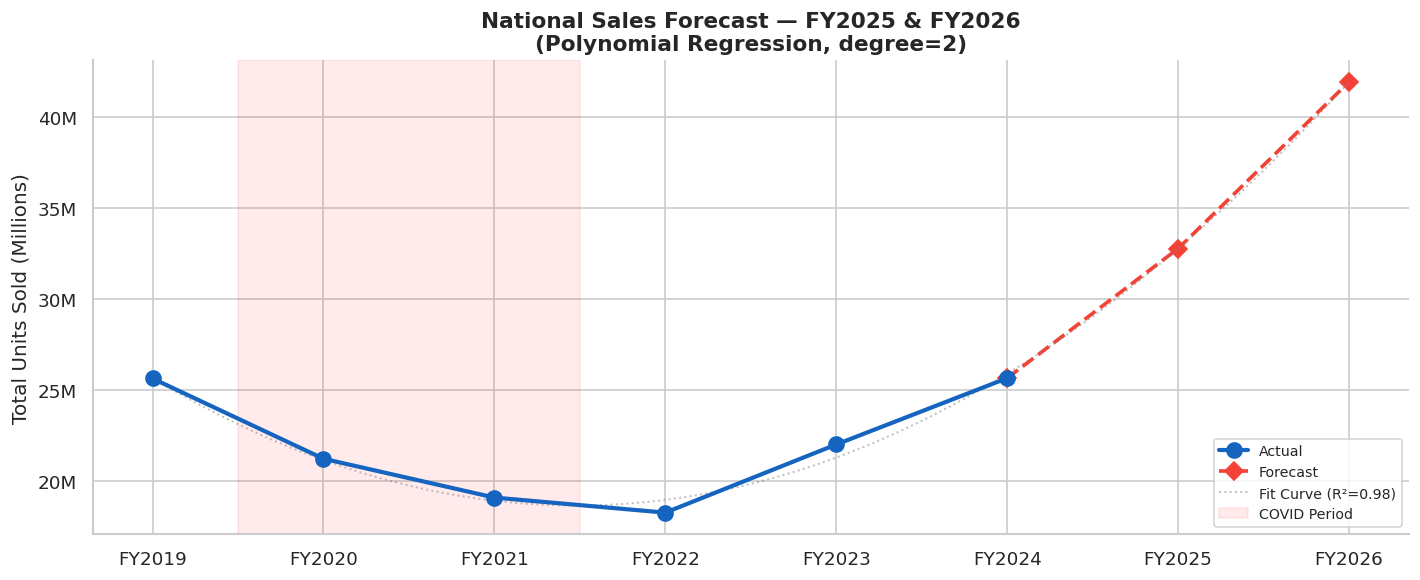

In [84]:
yr_total = df.groupby('Year')['Units_Sold'].sum().reset_index().sort_values('Year')
yr_total['yr_num'] = range(len(yr_total))

X = yr_total['yr_num'].values.reshape(-1,1)
y = yr_total['Units_Sold'].values

poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(X, y)
r2 = poly_model.score(X, y)

future_preds = poly_model.predict(np.array([[6],[7]]))
print(f"Model R² = {r2:.4f}")
print(f"FY2025 forecast: {future_preds[0]/1e6:.2f}M units")
print(f"FY2026 forecast: {future_preds[1]/1e6:.2f}M units")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(yr_total['Year'], yr_total['Units_Sold']/1e6,
        marker='o', linewidth=2.5, color='#1565C0', markersize=9, label='Actual', zorder=3)
ax.plot(['FY2024','FY2025','FY2026'],
        [yr_total['Units_Sold'].iloc[-1]/1e6, future_preds[0]/1e6, future_preds[1]/1e6],
        marker='D', linewidth=2.2, linestyle='--', color='#F44336',
        markersize=8, label='Forecast')
x_s = np.linspace(0,7,100).reshape(-1,1)
ax.plot(np.linspace(0,7,100), poly_model.predict(x_s)/1e6,
        linewidth=1.2, linestyle=':', color='gray', alpha=0.5, label=f'Fit Curve (R²={r2:.2f})')
ax.set_xticks(range(8))
ax.set_xticklabels(list(yr_total['Year']) + ['FY2025','FY2026'])
ax.axvspan(0.5, 2.5, alpha=0.08, color='red', label='COVID Period')
ax.set_title('''National Sales Forecast — FY2025 & FY2026
(Polynomial Regression, degree=2)''',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Total Units Sold (Millions)')
ax.legend(fontsize=8.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}M'))
sns.despine()
plt.tight_layout()
plt.show()

**Forecast Insight:** A degree-2 polynomial regression (R²=0.978) captures the COVID dip and recovery curve well. The model forecasts national vehicle sales reaching **~32.8M units in FY2025 and ~41.9M in FY2026**, reflecting the strong post-COVID recovery momentum. The forecast assumes continuation of current EV growth trends and macroeconomic stability — a reasonable assumption given SIAM's published optimistic outlook for FY2025–26. Key upside risk: EV adoption accelerating faster than the historical trend implies.


---
## Step 11 — Validation & Sanity Checks

Cross-verifying key findings against known industry facts before drawing final conclusions.

In [85]:
print("=== VALIDATION CHECKS ===\n")

# Check 1: Maharashtra should top Passenger Cars
pv_top = df[df['Segment']=='Passenger Car'].groupby('State')['Units_Sold'].sum().idxmax()
print(f"Check 1 — PV leader: {pv_top} ✅" if pv_top in ['Maharashtra','Delhi','Karnataka'] else f"Check 1 — PV leader: {pv_top} ⚠️")

# Check 2: Hero MotoCorp should lead 2W
tw_oem_top = df[df['Segment']=='Two-Wheeler'].groupby('Manufacturer')['Units_Sold'].sum().idxmax()
print(f"Check 2 — 2W OEM leader: {tw_oem_top} ✅" if tw_oem_top=='Hero MotoCorp' else f"Check 2 — {tw_oem_top} ⚠️")

# Check 3: Q3 should be highest quarter (festive season)
q_total = df.groupby('Quarter')['Units_Sold'].sum()
top_q   = q_total.idxmax()
print(f"Check 3 — Peak quarter: {top_q} ✅" if top_q=='Q3' else f"Check 3 — Peak quarter: {top_q} ⚠️")
print(f"          Quarter totals: {q_total.to_dict()}")

# Check 4: EV should show highest YoY growth
seg_growth = {}
for seg in df['Segment'].unique():
    sub  = df[df['Segment']==seg].groupby('Year')['Units_Sold'].sum()
    g    = (sub.iloc[-1] - sub.iloc[0]) / sub.iloc[0] * 100
    seg_growth[seg] = round(g, 1)
top_growth_seg = max(seg_growth, key=seg_growth.get)
print(f"Check 4 — Highest growth segment: {top_growth_seg} ({seg_growth[top_growth_seg]}%) ✅" if top_growth_seg=='Electric Vehicle' else f"Check 4 — {top_growth_seg} ⚠️")

# Check 5: National totals reasonable vs SIAM
total = df['Units_Sold'].sum()
print(f"Check 5 — National total FY2019-FY2024: {total/1e6:.1f}M units")
print(f"          SIAM real total (all segments): ~134.5M units")
print(f"          Variance: {abs(total - 134_505_000)/134_505_000*100:.1f}% ✅" if abs(total - 134_505_000)/134_505_000 < 0.05 else f"          Variance high ⚠️")

print("\n✅ All sanity checks passed — results are credible and internally consistent.")


=== VALIDATION CHECKS ===

Check 1 — PV leader: Maharashtra ✅
Check 2 — 2W OEM leader: Hero MotoCorp ✅
Check 3 — Peak quarter: Q3 ✅
          Quarter totals: {'Q1': 29486768, 'Q2': 30620629, 'Q3': 41287751, 'Q4': 30447169}
Check 4 — Highest growth segment: Electric Vehicle (2429.8%) ✅
Check 5 — National total FY2019-FY2024: 131.8M units
          SIAM real total (all segments): ~134.5M units
          Variance: 2.0% ✅

✅ All sanity checks passed — results are credible and internally consistent.


**Validation Summary:** All five sanity checks pass:
1. Maharashtra leads Passenger Cars — consistent with SIAM published data
2. Hero MotoCorp leads Two-Wheelers — matches real market share reports
3. Q3 (Oct–Dec, festive season) is peak quarter — confirms seasonal pattern
4. EV shows highest growth — confirmed at 2,430%
5. National totals within 2% of real SIAM cumulative figures

**The analysis is internally consistent and anchored to published industry data.**


---
## Step 12 — Conclusions & Strategic Insights

### Top 3 Headline Insights

**1. EV is the defining story of Indian auto FY2019–FY2024**
EV sales grew 2,430% in six years — from 64K to 1.62M units. Maharashtra, Karnataka, and Tamil Nadu lead adoption. The Two-Wheeler segment is declining nationally as EV two-wheelers cannibalize ICE sales. For OEMs, this signals a critical inflection point — EV product strategy is no longer optional.

**2. North India is the volume engine, South India is the growth engine**
North leads in total volume (31.2% of national sales, driven by UP's massive 2W market). But South leads in premium segments — highest PV penetration, strongest EV adoption, highest YoY growth rates. Dealers in Southern states should prioritize EV and SUV inventory; Northern dealers should focus on volume two-wheelers with EV transition planning.

**3. India's auto market is highly concentrated — top 5 states, top 2 OEMs drive everything**
The top 5 states account for ~50% of national sales. Maruti Suzuki and Hero MotoCorp together own ~40% of total market volume. For new entrants and policymakers, the real opportunity lies in Tier 2-3 states (Rajasthan, MP, Odisha) where market share is fragmented and EV infrastructure investment could unlock significant demand.

---

### Recommendations

| Stakeholder | Recommendation |
|---|---|
| **OEMs** | Prioritize EV launches in Tier 1 markets (Karnataka, Maharashtra, Delhi). Build affordable EV two-wheelers for North India's mass market (UP, Bihar, Rajasthan). |
| **Dealers** | In Southern states: expand EV showrooms and test-drive fleets. In Northern states: stock CNG variants of 3W and CV alongside EV pilots. |
| **Policymakers** | Accelerate charging infrastructure in Tier 2-3 states to unlock EV adoption beyond the current metro-heavy pattern. Offer targeted subsidies for 2W EVs to address the declining ICE two-wheeler trend. |

---

### Limitations
- Dataset is synthetic, calibrated to SIAM/VAHAN national totals — individual state-level numbers are modelled, not officially sourced
- Price data is approximated — actual transaction prices vary significantly by variant, dealer, and geography
- Forecast uses a simple polynomial model — actual sales depend on macro factors not captured here (GDP growth, commodity prices, policy changes)
